# First-Quadrant I-V Physical Modeling at Room Temperature


In [1]:
# Import the room-temperature data loader, fixed surface PINN, and physical channel-current model.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from DeviceData import load_iv_characteristics
from SurfacePotential import load_surface_potential_pkl, surface_potential
from Channel_Current_Ich import effective_vds, channel_current_physical
from IVPhysicalModel import IVPhysicalParameters, save_iv_physical_pkl


## Room-temperature data and physical parameters


In [2]:
# Load only the 25 C output and transfer datasets.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"

dataset = load_iv_characteristics(TEMPLATE_DIR, transfer_vds=20.0)
print(dataset.groupby(["characteristic", "T_C"]).size())
print("Total I-V points =", len(dataset))

def to_tensor(name):
    return torch.tensor(dataset[name].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)

Vgs_data = to_tensor("Vgs")
Vds_data = to_tensor("Vds")
T_K_data = to_tensor("T_K")
Ids_data = to_tensor("Ids")
output_mask = torch.tensor((dataset["characteristic"] == "output").to_numpy(), device=device)
transfer_mask = torch.tensor((dataset["characteristic"] == "transfer").to_numpy(), device=device)

assert np.allclose(dataset["T_C"].to_numpy(), 25.0)


characteristic  T_C 
output          25.0    157
transfer        25.0     27
dtype: int64
Total I-V points = 184


In [3]:
# Use the same room-temperature surface-potential constants as the phis PINN pretraining stage.
NA = 1.0e16
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Eg = 3.26
Ec_minus_Ei = Eg / 2.0
Qox = 1.602e-7

surface_model, surface_checkpoint = load_surface_potential_pkl(
    BASE_DIR / "phis_PINN.pkl",
    device=device,
    dtype=dtype,
    freeze=True,
)

iv_parameters = IVPhysicalParameters(Lch_cm=1.0e-4).to(device=device, dtype=dtype)

# Keep surface-potential parameters fixed at the values used by phis_PINN.pkl.
for name, parameter in iv_parameters.named_parameters():
    if name in {
        "log_Dit_edge0",
        "Dit_edge_t1",
        "Dit_edge_t2",
        "Vfbs0_ref",
        "Vfbs0_t1",
        "Vfbs0_t2",
        "mu_t1",
        "mu_t2",
        "lambda_t1",
        "vth_t1",
    }:
        parameter.requires_grad_(False)


## Room-temperature physical I-V parameter optimization


In [4]:
# Evaluate the complete room-temperature surface-potential-based I-V model.
def evaluate_iv(Vgs, Vds, T_K):
    values = iv_parameters.values(Vgs, T_K)
    Vdseff = effective_vds(Vds, values["Vdssat"], values["delta"])
    phis_s0 = surface_potential(
        surface_model,
        Vgs,
        torch.zeros_like(Vgs),
        T=T_K,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
    )
    phis_sL = surface_potential(
        surface_model,
        Vgs,
        Vdseff,
        T=T_K,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
    )
    Ids, mu_eff, I_phi = channel_current_physical(
        Vgs,
        Vds,
        Vdseff,
        phis_s0,
        phis_sL,
        Vfbs0=Vfbs0,
        Cox=Cox,
        Qox=Qox,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Ec_minus_Ei=Ec_minus_Ei,
        T=T_K,
        NA=NA,
        Eg=Eg,
        eps_sic=eps_sic,
        K_current_gain=values["K"],
        mu_lf_cm2_Vs=values["mu_lf"],
        lambda_clm=values["lambda_clm"],
        Lch_cm=values["Lch_cm"],
        vsat_cm_s=values["vsat"],
    )
    return Ids, Vdseff, phis_s0, phis_sL, mu_eff, I_phi


In [5]:
# Optimize only the room-temperature physical I-V parameters while keeping phis_PINN.pkl fixed.
EPOCHS = 4000
LEARNING_RATE = 1.0e-4
CURRENT_SCALE = max(float(np.abs(dataset["Ids"]).max()), 1.0)
trainable_iv_parameters = [parameter for parameter in iv_parameters.parameters() if parameter.requires_grad]
optimizer = torch.optim.Adam(trainable_iv_parameters, lr=LEARNING_RATE)
loss_history = []
best_loss = float("inf")
best_iv_state = None

for epoch in range(EPOCHS):
    optimizer.zero_grad(set_to_none=True)
    Ids_pred, _, _, _, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)
    output_loss = torch.mean(((Ids_pred[output_mask] - Ids_data[output_mask]) / CURRENT_SCALE) ** 2)
    transfer_loss = torch.mean(((Ids_pred[transfer_mask] - Ids_data[transfer_mask]) / CURRENT_SCALE) ** 2)
    loss = 0.5 * output_loss + 0.5 * transfer_loss
    if not torch.isfinite(loss):
        raise RuntimeError(f"Non-finite loss at epoch {epoch}")
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable_iv_parameters, max_norm=10.0)
    optimizer.step()
    value = loss.item()
    loss_history.append(value)
    if value < best_loss:
        best_loss = value
        best_iv_state = {k: v.detach().cpu().clone() for k, v in iv_parameters.state_dict().items()}
    if epoch % 200 == 0 or epoch == EPOCHS - 1:
        rmse = torch.sqrt(torch.mean((Ids_pred.detach() - Ids_data) ** 2)).item()
        print(f"Epoch {epoch:4d} | loss = {value:.6e} | RMSE = {rmse:.4f} A")

iv_parameters.load_state_dict(best_iv_state, strict=True)
print("Best loss =", best_loss)
print(pd.DataFrame(iv_parameters.report(temperatures_c=(25.0,))))


Epoch    0 | loss = 8.119953e-02 | RMSE = 21.1787 A
Epoch  200 | loss = 7.893495e-02 | RMSE = 20.7308 A
Epoch  400 | loss = 7.665777e-02 | RMSE = 20.2707 A
Epoch  600 | loss = 7.437335e-02 | RMSE = 19.7986 A
Epoch  800 | loss = 7.208805e-02 | RMSE = 19.3149 A
Epoch 1000 | loss = 6.983159e-02 | RMSE = 18.8254 A
Epoch 1200 | loss = 6.761354e-02 | RMSE = 18.3318 A
Epoch 1400 | loss = 6.544852e-02 | RMSE = 17.8372 A
Epoch 1600 | loss = 6.334406e-02 | RMSE = 17.3432 A
Epoch 1800 | loss = 6.131932e-02 | RMSE = 16.8547 A
Epoch 2000 | loss = 5.940032e-02 | RMSE = 16.3788 A
Epoch 2200 | loss = 5.760093e-02 | RMSE = 15.9203 A
Epoch 2400 | loss = 5.586517e-02 | RMSE = 15.4770 A
Epoch 2600 | loss = 5.387282e-02 | RMSE = 15.0277 A
Epoch 2800 | loss = 5.201074e-02 | RMSE = 14.6078 A
Epoch 3000 | loss = 5.034317e-02 | RMSE = 14.2217 A
Epoch 3200 | loss = 4.878787e-02 | RMSE = 13.8664 A
Epoch 3400 | loss = 4.734401e-02 | RMSE = 13.5412 A
Epoch 3600 | loss = 4.606694e-02 | RMSE = 13.2522 A
Epoch 3800 |

## Save the physical I-V parameters and model bundle


In [6]:
# Save the fitted room-temperature physical parameters without changing phis_PINN.pkl.
save_iv_physical_pkl(
    BASE_DIR / "Ich_physical_25C.pkl",
    iv_parameters,
    training_metadata={
        "temperature_C": 25.0,
        "best_loss": best_loss,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "surface_PINN_file": "phis_PINN.pkl",
        "surface_PINN_frozen": True,
    },
)

bundle = {
    "format_version": 2,
    "model_name": "SiC_MOSFET_First_Quadrant_IV_25C",
    "temperature_C": 25.0,
    "surface_potential_PINN": torch.load(BASE_DIR / "phis_PINN.pkl", map_location="cpu", weights_only=False),
    "Ich_physical": torch.load(BASE_DIR / "Ich_physical_25C.pkl", map_location="cpu", weights_only=False),
}
torch.save(bundle, BASE_DIR / "Ich_Model_25C.pkl")
print("Saved Ich_physical_25C.pkl and Ich_Model_25C.pkl")


Saved Ich_physical_25C.pkl and Ich_Model_25C.pkl


## Accuracy and room-temperature curve comparison


In [7]:
# Report the room-temperature fit error for the output and transfer datasets.
surface_model.eval()
iv_parameters.eval()
with torch.no_grad():
    Ids_fit, _, _, _, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)
error = Ids_fit - Ids_data
overall_rmse = torch.sqrt(torch.mean(error**2)).item()
output_rmse = torch.sqrt(torch.mean(error[output_mask]**2)).item()
transfer_rmse = torch.sqrt(torch.mean(error[transfer_mask]**2)).item()
print(f"Overall RMSE = {overall_rmse:.4f} A")
print(f"Output RMSE = {output_rmse:.4f} A")
print(f"Transfer RMSE = {transfer_rmse:.4f} A")


Overall RMSE = 12.7789 A
Output RMSE = 11.9097 A
Transfer RMSE = 16.9727 A


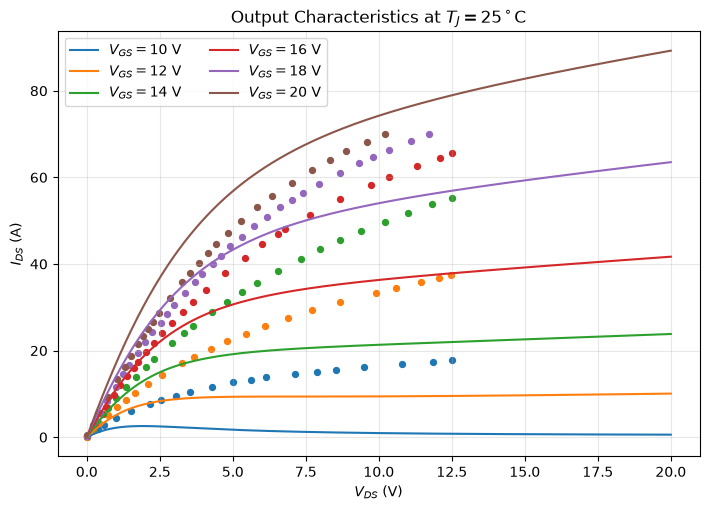

In [8]:
# Plot the measured and modeled room-temperature output characteristics.
def predict_curve(vgs_value, vds_max=20.0, points=300):
    Vds = torch.linspace(0.0, vds_max, points, dtype=dtype, device=device).reshape(-1, 1)
    Vgs = torch.full_like(Vds, float(vgs_value))
    T_K = torch.full_like(Vds, 298.15)
    with torch.no_grad():
        Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
    return Vds.cpu().numpy().reshape(-1), Ids.cpu().numpy().reshape(-1)

plt.figure(figsize=(7.2, 5.2))
part_t = dataset[dataset["characteristic"] == "output"]
for vgs_value in sorted(part_t["Vgs"].unique()):
    measured = part_t[np.isclose(part_t["Vgs"], vgs_value)]
    plt.scatter(measured["Vds"], measured["Ids"], s=18)
    x, y = predict_curve(vgs_value, vds_max=max(20.0, measured["Vds"].max()))
    plt.plot(x, y, label=rf"$V_{{GS}}={vgs_value:g}$ V")
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ (A)")
plt.title(r"Output Characteristics at $T_J=25^\circ$C")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


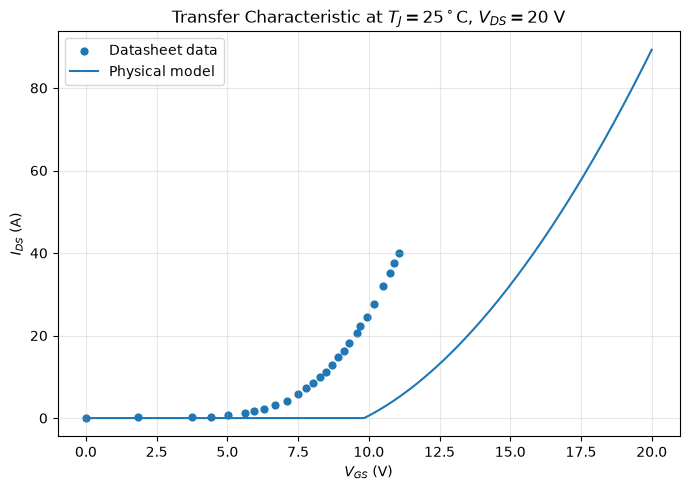

In [9]:
# Plot the measured and modeled room-temperature transfer characteristic.
measured = dataset[dataset["characteristic"] == "transfer"]
Vgs = torch.linspace(0.0, 20.0, 400, dtype=dtype, device=device).reshape(-1, 1)
Vds = torch.full_like(Vgs, 20.0)
T_K = torch.full_like(Vgs, 298.15)
with torch.no_grad():
    Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
plt.figure(figsize=(7.0, 5.0))
plt.scatter(measured["Vgs"], measured["Ids"], s=24, label="Datasheet data")
plt.plot(Vgs.cpu(), Ids.cpu(), label="Physical model")
plt.xlabel(r"$V_{GS}$ (V)")
plt.ylabel(r"$I_{DS}$ (A)")
plt.title(r"Transfer Characteristic at $T_J=25^\circ$C, $V_{DS}=20$ V")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


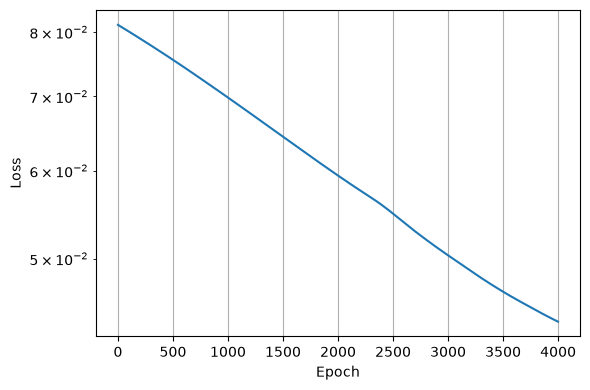

In [10]:
# Plot the room-temperature I-V training objective.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
